# Machine Learning <> Data Preprocessing & Train-Test Split

> **Dataset:** We will use the famous **Titanic dataset**, it contains information about passengers on the Titanic ship and whether they survived or not.
>
> Our goal: *Can we predict who will survive based on age, gender, ticket class, etc.?*

---
## Step 0 — Install & Import Libraries

Think of libraries as **toolboxes**. Instead of building every tool from scratch, we borrow ready-made ones.

| Library | Purpose |
|---|---|
| `pandas` | Working with tables (like Excel in Python) |
| `numpy` | Math and numbers |
| `matplotlib` | Drawing charts |
| `seaborn` | Prettier charts |
| `sklearn` | Machine Learning tools |

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 1 — What is a Dataset?

A dataset is like a **school result card**:
- Each **row** = one student (one sample/record)
- Each **column** = one subject or attribute (one feature)
- One special column = what we want to predict (the **target/label**)

```
Name     | Age | Gender | Class | Survived  ← target (what we predict)
---------|-----|--------|-------|----------
Ali      |  22 | Male   |   3   |    0
Sara     |  35 | Female |   1   |    1
Ahmad    |  28 | Male   |   2   |    0
```

**Survived = 1** means the person survived. **0** means they did not.

---
## 🔍 Step 2 — Loading & Exploring Real Data

Now let's load the **real Titanic dataset**.

> 🚢 *The Titanic was a ship that sank in 1912. 891 passengers are in our dataset. We want to build a model that predicts: given a passenger's details, did they survive?*

In [ ]:
# Load the Titanic dataset directly from the internet
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("✅ Dataset loaded!")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

✅ Dataset loaded!
Total rows: 891
Total columns: 12


In [ ]:
# View the first 5 rows — like opening the first page of a register
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check column names and data types
# int64 = whole numbers | float64 = decimal numbers | object = text/string
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Basic statistics — min, max, average of each numerical column
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# What columns do we have?
print("Column names:")
for col in df.columns:
    print(f"  - {col}")

Column names:
  - PassengerId
  - Survived
  - Pclass
  - Name
  - Sex
  - Age
  - SibSp
  - Parch
  - Ticket
  - Fare
  - Cabin
  - Embarked


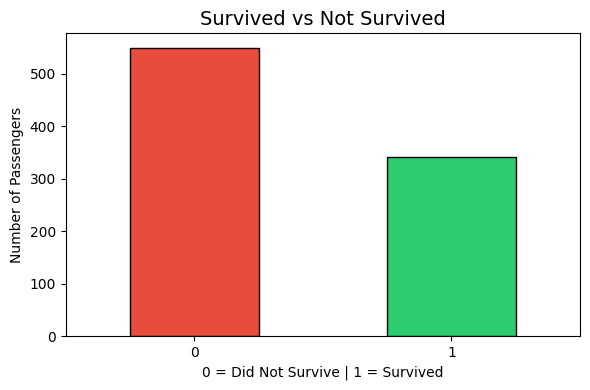

Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


In [ ]:
# Prompt: Create a bar chart showing the count of survived vs not survived passengers.

plt.figure(figsize=(6, 4))
df['Survived'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Survived vs Not Survived', fontsize=14)
plt.xlabel('0 = Did Not Survive | 1 = Survived')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['Survived'].value_counts())
print(f"\nSurvival rate: {df['Survived'].mean()*100:.1f}%")

---
## Step 3 — Handling Missing Values

Real-world data is **never perfect**. Some values will be missing; just like a form where someone skipped a question.

**Why missing values are a problem:**
Most ML algorithms cannot work with empty/NaN values. We must handle them first.

**Three strategies:**
| Strategy | When to use |
|---|---|
| Drop the row | When very few rows are missing |
| Drop the col | When too many missing values i.e. > 50%|
| Fill with mean/median | For numerical columns |
| Fill with mode | For categorical (text) columns |

In [ ]:
# Check how many values are missing in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print("Missing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing values per column:
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


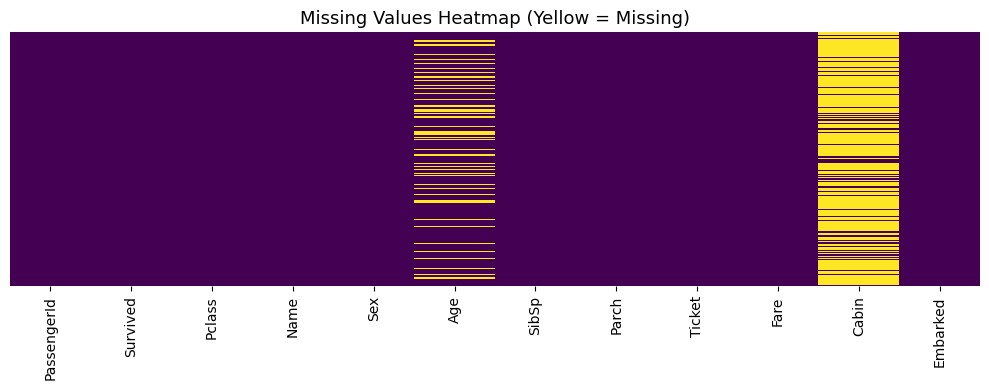

In [ ]:
# Prompt: Create a heatmap to visualize missing values in the DataFrame.

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.show()

Let's now visualize the distribution of the 'Age' column *before* any imputation, to see its original scatter and the impact of missing values.

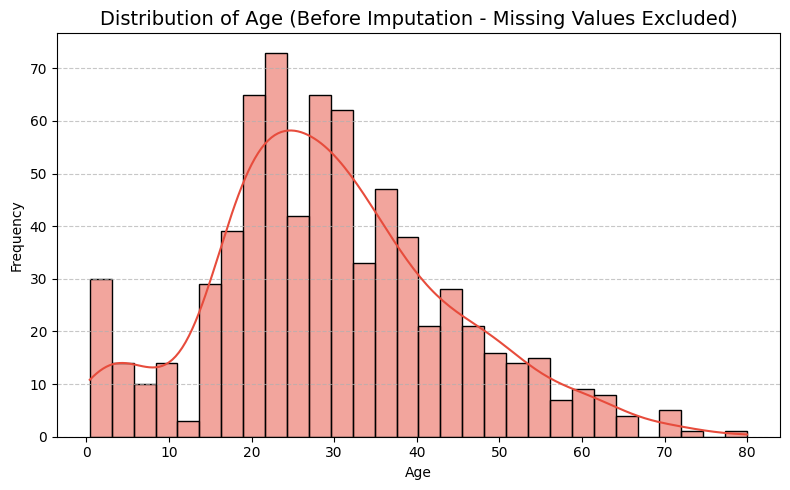

In [ ]:
# Prompt: Create a histogram of the 'Age' distribution before imputation.

plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='#e74c3c', edgecolor='black') # .dropna() to only plot existing values
plt.title('Distribution of Age (Before Imputation - Missing Values Excluded)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

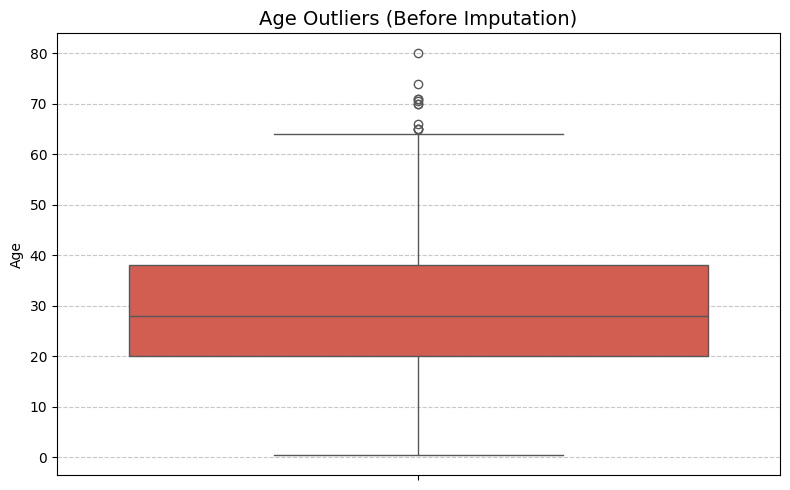

Number of missing 'Age' values in original data: 177


In [ ]:
# Prompt: Create a boxplot to show 'Age' outliers before imputation.

plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Age'].dropna(), color='#e74c3c')
plt.title('Age Outliers (Before Imputation)', fontsize=14)
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Number of missing 'Age' values in original data: {df['Age'].isnull().sum()}")

In [ ]:
# Make a copy so we don't mess up the original data
# Good practice: always work on a copy!
df_clean = df.copy()

In [ ]:
# --- Fix Age (numerical) → fill with MEDIAN ---
# Median is better than mean when there are extreme values (outliers)
median_age = df_clean['Age'].median()
print(f"Median age: {median_age}")
df_clean['Age'] = df_clean['Age'].fillna(median_age)

Median age: 28.0


In [ ]:
# --- Fix Embarked (categorical) → fill with MODE (most common value) ---
mode_embarked = df_clean['Embarked'].mode()[0]
print(f"Most common Embarked value: {mode_embarked}")
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

Most common Embarked value: S


In [ ]:
# --- Drop Cabin column → too many missing values (77%) → not useful ---
df_clean = df_clean.drop(columns=['Cabin'])

print("\n✅ Missing values after cleaning:")
print(df_clean.isnull().sum())


✅ Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Let's visualize the distribution of the 'Age' column after handling missing values. A histogram can show us the scatter and frequency of ages.

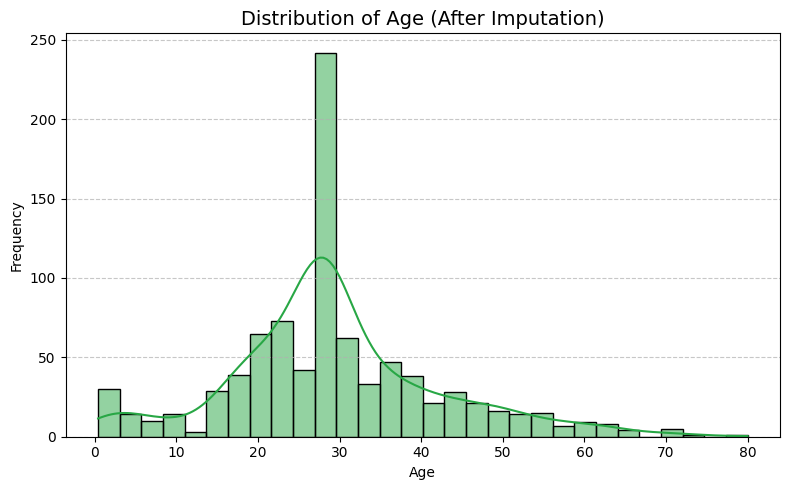

In [ ]:
# Prompt: Create a histogram of the 'Age' distribution after imputation.

plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='#28a745', edgecolor='black')
plt.title('Distribution of Age (After Imputation)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## Step 4 — Encoding Categorical Data

Computers only understand **numbers**. They cannot read words like "Male" or "Female".
We must convert text into numbers — this is called **encoding**.

**Two main methods:**

| Method | How it works | Use when |
|---|---|---|
| Label Encoding | Male=0, Female=1 | Only 2 categories |
| One-Hot Encoding | Creates new columns for each category | 3+ categories |

> *Label encoding for 3+ categories can mislead the model — it thinks 0 < 1 < 2 meaning there is an order, which may not be true.*

In [ ]:
# See what categorical columns we have
print("Categorical columns:")
print(df_clean.select_dtypes(include='object').columns.tolist())

print("\nUnique values in each:")
for col in df_clean.select_dtypes(include='object').columns:
    print(f"  {col}: {df_clean[col].unique()}")

Categorical columns:
['Name', 'Sex', 'Ticket', 'Embarked']

Unique values in each:
  Name: ['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima' 'Fynney, Mr. Joseph J' 'Beesley, Mr. Lawrence'
 'McGowan, Miss. Anna "Annie"' 'Sloper, Mr. William Thompson'
 'Palsson, Miss. Torborg Danira'
 'Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)'
 'Emir, Mr

In [ ]:
# --- Label Encoding for Sex (only 2 values: male/female) ---
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
print("Sex column after encoding:")
print(df_clean['Sex'].value_counts())

Sex column after encoding:
Sex
0    577
1    314
Name: count, dtype: int64


In [ ]:
# --- One-Hot Encoding for Embarked (3 values: S, C, Q) ---
# pd.get_dummies creates a new column for each category
print("Before One-Hot Encoding:")
print(df_clean['Embarked'].value_counts())

df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
# drop_first=True removes one column to avoid redundancy

print("\nNew columns created:")
print([col for col in df_clean.columns if 'Embarked' in col])

Before One-Hot Encoding:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

New columns created:
['Embarked_Q', 'Embarked_S']


In [ ]:
# Drop columns that are not useful for prediction
# Name, Ticket, PassengerId are just identifiers, not useful features
df_clean = df_clean.drop(columns=['Name', 'Ticket', 'PassengerId'])

print("Remaining columns after cleanup:")
print(df_clean.columns.tolist())
print("\nDataset shape:", df_clean.shape)
df_clean.head()

Remaining columns after cleanup:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Dataset shape: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


---
## Step 5 — Feature Scaling

Look at these two columns:
- `Age`: values between 0–80
- `Fare`: values between 0–512

The model may **think Fare is more important** just because its numbers are bigger!
Scaling brings all features to the **same range**.

**Two common methods:**

| Method | Formula | Result |
|---|---|---|
| Min-Max Scaling | (x - min) / (max - min) | Values between 0 and 1 |
| Standard Scaling | (x - mean) / std | Mean=0, most values between -3 and 3 |

In [ ]:
# See the current range of numerical features
print("Before Scaling:")
print(df_clean[['Age', 'Fare', 'SibSp', 'Parch']].describe().loc[['min', 'max', 'mean']])

Before Scaling:
            Age        Fare     SibSp     Parch
min    0.420000    0.000000  0.000000  0.000000
max   80.000000  512.329200  8.000000  6.000000
mean  29.361582   32.204208  0.523008  0.381594


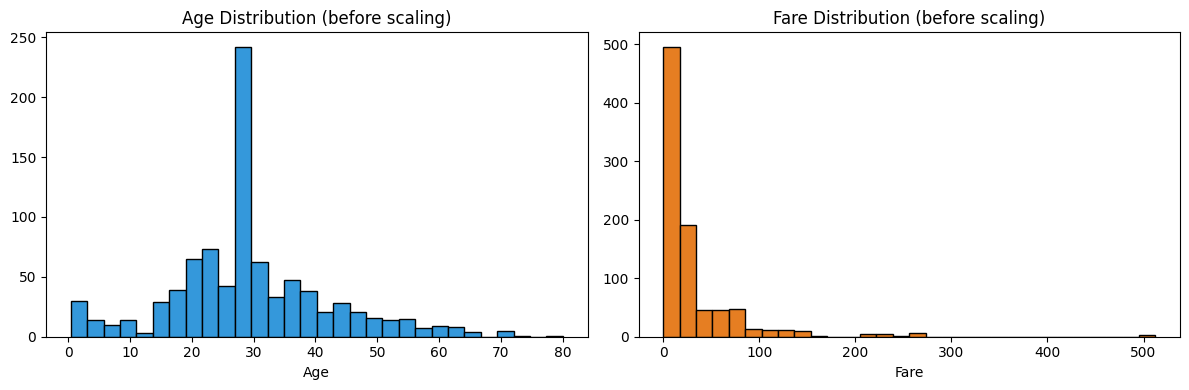

In [ ]:
# Prompt: Create histograms comparing the distributions of 'Age' and 'Fare' before scaling.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Age'], bins=30, color='#3498db', edgecolor='black')
axes[0].set_title('Age Distribution (before scaling)')
axes[0].set_xlabel('Age')

axes[1].hist(df_clean['Fare'], bins=30, color='#e67e22', edgecolor='black')
axes[1].set_title('Fare Distribution (before scaling)')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

In [ ]:
# Apply Standard Scaling to numerical columns
cols_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("After Standard Scaling:")
print(df_clean[cols_to_scale].describe().loc[['min', 'max', 'mean']].round(3))

After Standard Scaling:
        Age   Fare  SibSp  Parch
min  -2.224 -0.648 -0.475 -0.474
max   3.892  9.667  6.784  6.974
mean  0.000  0.000  0.000  0.000


---
## Step 6 — Separating Features (X) and Target (y)

Before splitting into train/test, we separate:
- **X** = all input columns (features):  *what we know about the passenger*
- **y** = the target column: *what we want to predict (Survived)*

> 📌 X is the question paper. y is the answer key.

In [ ]:
# Separate features and target
X = df_clean.drop(columns=['Survived'])  # everything except Survived
y = df_clean['Survived']                  # only the Survived column

print("X (Features) shape:", X.shape)
print("y (Target) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget values (first 10):")
print(y.values[:10])

X (Features) shape: (891, 8)
y (Target) shape: (891,)

Feature columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Target values (first 10):
[0 1 1 1 0 0 0 0 1 1]


---
## Step 7 — Train-Test Split

We **cannot** test a model on the same data it learned from; that's cheating!

Imagine a teacher gives students the same exact exam questions they practiced. They'll all pass but did they really learn?

We split our data into:
- **Training set (80%)**: model learns from this
- **Test set (20%)**: we evaluate the model on this (model has never seen it!)

```
Total Data (891 rows)
├── Training Set (712 rows) ← model learns here
└── Test Set     (179 rows) ← we test here
```

In [ ]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,            # features
    y,            # target
    test_size=0.2,        # 20% for testing
    # random_state=42,      # so everyone gets same split (reproducibility)
    stratify=y            # keep same survival ratio in both sets
)

print("Train-Test Split Results:")
print(f"  Total samples:      {len(X)}")
print(f"  Training samples:   {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing samples:    {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")

Train-Test Split Results:
  Total samples:      891
  Training samples:   712 (80%)
  Testing samples:    179  (20%)


In [ ]:
# Verify survival ratio is similar in both sets (thanks to stratify=y)
print("Survival rate in training set:", y_train.mean().round(3))
print("Survival rate in test set:    ", y_test.mean().round(3))
print("\n✅ Both sets have similar survival rates — good split!")

Survival rate in training set: 0.383
Survival rate in test set:     0.385

✅ Both sets have similar survival rates — good split!


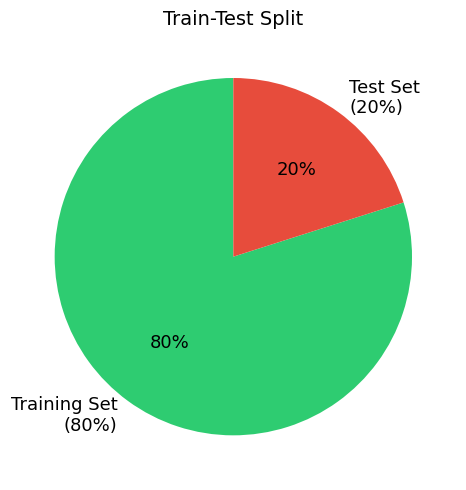

In [ ]:
# Prompt: Create a pie chart showing the train-test split proportions.
labels = ['Training Set\n(80%)', 'Test Set\n(20%)']
sizes = [len(X_train), len(X_test)]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 13})
plt.title('Train-Test Split', fontsize=14)
plt.tight_layout()
plt.show()

---
## ⚠️ What is Data Leakage? (Important Concept!)

**Data leakage** happens when information from the test set accidentally gets used during training.

This gives **falsely high accuracy**, the model seems great but fails in real world.

**Common mistake — Wrong way:**
```python
# ❌ WRONG — scaling BEFORE splitting
scaler.fit_transform(X)          # learns stats from ALL data including test
X_train, X_test = split(X)       # test data info already leaked!
```

**Correct way:**
```python
# ✅ CORRECT — split FIRST, then scale
X_train, X_test = split(X)
scaler.fit(X_train)              # learn stats from training only
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)  # apply same stats to test
```

In [ ]:
# Let's demonstrate the CORRECT way to scale after splitting
# First reload without scaling
df_raw = pd.read_csv(url)
df_raw = df_raw.copy()

# Clean
df_raw['Age'] = df_raw['Age'].fillna(df_raw['Age'].median())
df_raw['Embarked'] = df_raw['Embarked'].fillna(df_raw['Embarked'].mode()[0])
df_raw = df_raw.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])
df_raw['Sex'] = df_raw['Sex'].map({'male': 0, 'female': 1})
df_raw = pd.get_dummies(df_raw, columns=['Embarked'], drop_first=True)

X2 = df_raw.drop(columns=['Survived'])
y2 = df_raw['Survived']

# Split FIRST
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Scale AFTER split — fit only on training data
scaler2 = StandardScaler()
cols = ['Age', 'Fare', 'SibSp', 'Parch']

X2_train[cols] = scaler2.fit_transform(X2_train[cols])   # fit + transform on train
X2_test[cols]  = scaler2.transform(X2_test[cols])         # only transform on test

print("✅ Correct pipeline: split first → scale after")
print(f"Training set shape: {X2_train.shape}")
print(f"Test set shape:     {X2_test.shape}")

✅ Correct pipeline: split first → scale after
Training set shape: (712, 8)
Test set shape:     (179, 8)


---
## Quick Model to See It All in Action!

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train a simple Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X2_train, y2_train)

# Predict on test set
y_pred = model.predict(X2_test)

# Evaluate
accuracy = accuracy_score(y2_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y2_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Model Accuracy: 78.8%

Detailed Report:
                 precision    recall  f1-score   support

Did Not Survive       0.77      0.94      0.84       110
       Survived       0.84      0.55      0.67        69

       accuracy                           0.79       179
      macro avg       0.81      0.74      0.76       179
   weighted avg       0.80      0.79      0.78       179



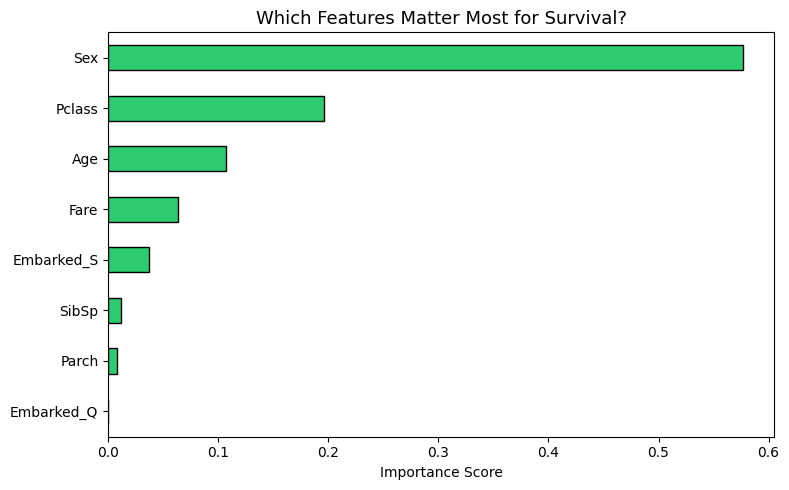

In [ ]:
# Prompt: Create a horizontal bar chart showing feature importances for survival prediction.
feature_importance = pd.Series(
    model.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.title('Which Features Matter Most for Survival?', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()